TASK 01
A backward pass by hand

• Build a tiny computation: a = w*x, then loss = (a - target)². Use x=3, w=1.0, target=12.

• Do the forward pass on paper: compute a, then the loss.

• Do the backward pass by hand: find d(loss)/d(a), then d(a)/d(w), then chain them for d(loss)/d(w).

• Verify d(loss)/d(w) numerically by nudging w and measuring the loss change.

• Read the gradient's sign: should w go up or down to reduce the loss? 

In [3]:
import numpy as np

x, w, target = 3, 1.0, 12

a = w * x
loss = (a - target) ** 2

print(a, loss)

dL_da = 2 * (a - target)
da_dw = x
dL_dw = dL_da * da_dw

print(dL_da, da_dw, dL_dw)


def compute_loss(w):
    return (w * x - target) ** 2


def numerical_gradient(w, h=1e-5):
    return (compute_loss(w + h) - compute_loss(w - h)) / (2 * h)


print("Analytical:", dL_dw)
print("Numerical :", numerical_gradient(w))

lr = 0.1

new_w = w - lr * dL_dw

print("Old loss:", compute_loss(w))
print("New loss:", compute_loss(new_w))

if dL_dw < 0:
    print("Increase w")
else:
    print("Decrease w")

3.0 81.0
-18.0 3 -54.0
Analytical: -54.0
Numerical : -53.99999999937676
Old loss: 81.0
New loss: 51.84000000000004
Increase w


Take one update step with lr=0.05 and
confirm the loss actually drops.

In [4]:
lr = 0.05

new_w = w - lr * dL_dw

print("Old loss:", compute_loss(w))
print("New loss:", compute_loss(new_w))



Old loss: 81.0
New loss: 0.8099999999999974


TASK 02
Gradient descent from scratch

Write gradient_descent(grad_fn, start, lr, steps) that returns the full history of positions.

• Use it to minimise f(x) = (x-5)² (gradient 2(x-5)) starting from x=0. Confirm it reaches x=5.

• Plot the function as a curve, with every step marked on it. Watch the steps shrink near the minimum.

• Print the first six positions. Confirm the jumps get smaller each step, and explain in one line why.

• Try a second function of your choice with a known minimum, and confirm your optimiser finds it.

Final x: 4.993810299803573
First six positions: [0, 1.0, 1.8, 2.4400000000000004, 2.9520000000000004, 3.3616]


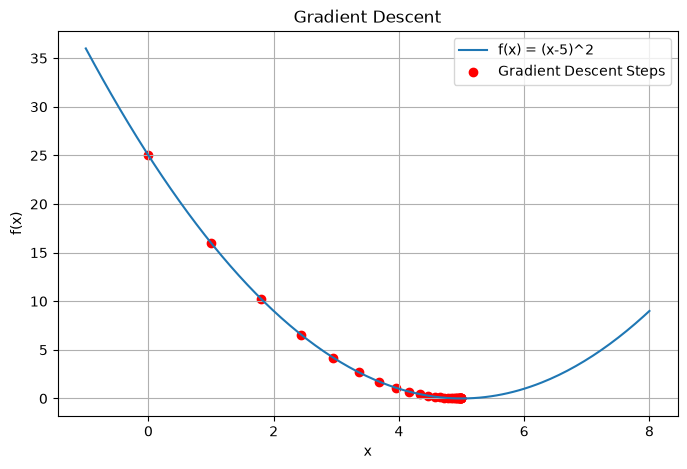


Observation:
The jumps get smaller because the gradient becomes smaller as x approaches the minimum.

Second Function
Final x: -1.9913344197250022
Known minimum: x = -2


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history


# Function 1: f(x) = (x - 5)^2
f = lambda x: (x - 5) ** 2
grad = lambda x: 2 * (x - 5)

history = gradient_descent(grad, start=0, lr=0.1, steps=30)

print("Final x:", history[-1])
print("First six positions:", history[:6])

# Plot the function and gradient descent steps
x = np.linspace(-1, 8, 200)

plt.figure(figsize=(8, 5))
plt.plot(x, f(x), label="f(x) = (x-5)^2")
plt.scatter(history, [f(i) for i in history], color="red", label="Gradient Descent Steps")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

print("\nObservation:")
print("The jumps get smaller because the gradient becomes smaller as x approaches the minimum.")


# Function 2: f(x) = (x + 2)^2
f2 = lambda x: (x + 2) ** 2
grad2 = lambda x: 2 * (x + 2)

history2 = gradient_descent(grad2, start=5, lr=0.1, steps=30)

print("\nSecond Function")
print("Final x:", history2[-1])
print("Known minimum: x = -2")

TASK 03
Sweep the learning rate until it breaks

Minimise (x-5)² from x=0 with learning rates 0.001, 0.01, 0.1, 0.5, 0.9, 1.0, and 1.05.

• For each, report where it ends after a fixed number of steps.

In [6]:
import numpy as np


def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history


# Function: f(x) = (x - 5)^2
f = lambda x: (x - 5) ** 2
grad = lambda x: 2 * (x - 5)

learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.05]

steps = 30

print("Learning Rate\tFinal x\t\tFinal Loss")

for lr in learning_rates:
    history = gradient_descent(grad, start=0, lr=lr, steps=steps)
    final_x = history[-1]
    final_loss = f(final_x)

    print(f"{lr:<12}\t{final_x:.6f}\t{final_loss:.6f}")

Learning Rate	Final x		Final Loss
0.001       	0.291460	22.170347
0.01        	2.272578	7.438829
0.1         	4.993810	0.000038
0.5         	5.000000	0.000000
0.9         	4.993810	0.000038
1.0         	0.000000	25.000000
1.05        	-82.247011	7612.040989


Plot three side-by-side descent paths: one too small (crawls), one just right (converges), one too large
(diverges).

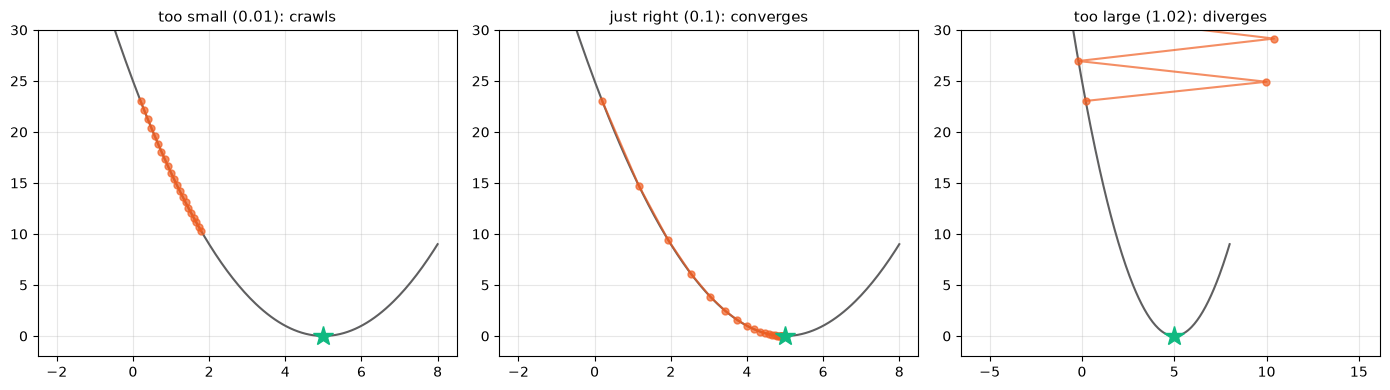

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x): return (x - 5)**2
def gradient_descent(grad_fn, start, lr, steps):
    x = start; hist = [x]
    for _ in range(steps):
        x = x - lr * grad_fn(x); hist.append(x)
    return np.array(hist)
grad = lambda x: 2 * (x - 5)

xs = np.linspace(-2, 8, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, lr, ttl in [(axes[0], 0.01, "too small (0.01): crawls"),
                    (axes[1], 0.1,  "just right (0.1): converges"),
                    (axes[2], 1.02, "too large (1.02): diverges")]:
    path = gradient_descent(grad, 0.2, lr, 20)
    ax.plot(xs, f(xs), color="#5F5F60", lw=1.5)
    ax.plot(path, f(path), "o-", color="#F05E22", alpha=0.7, markersize=5)
    ax.plot(5, 0, "*", color="#10B981", markersize=15)
    ax.set_title(ttl, fontsize=11); ax.grid(alpha=0.3)
    ax.set_ylim(-2, 30)
plt.tight_layout(); plt.show()

• Find, by experiment, the learning rate above which this function always diverges. For (x-5)² the threshold is a
clean round number — what is it?

• Write two sentences: what exactly does a too-large learning rate do, step by step, that makes it blow up?

In [7]:
lr = 0.1

while lr <= 2:
    history = gradient_descent(grad, 0, lr, 30)

    if abs(history[-1]) > 1e6:
        print("Diverges near:", lr)
        break

    lr += 0.01


'''
    A too-large learning rate makes the algorithm take steps that are larger than the distance to the minimum, 
    so it overshoots the minimum instead of getting closer.
    Each overshoot produces an even larger correction in the opposite direction, causing the updates to grow until the optimization diverges.
   
   
    '''

Diverges near: 1.260000000000001


'\n    A too-large learning rate makes the algorithm take steps that are larger than the distance to the minimum, \n    so it overshoots the minimum instead of getting closer.\n    Each overshoot produces an even larger correction in the opposite direction, causing the updates to grow until the optimization diverges.\n\n\n    '

TASK 04
Local minima and convexity

• Take a function with two minima, e.g. f(x) = xn - 4x² + 0.4x (gradient 4x³ - 8x + 0.4).

• Plot it and identify, by eye, the shallow local minimum and the deep global minimum.

• Run gradient descent from several starting points. Show that some starts reach the global minimum and others
get trapped in the local one.

• On the plot, draw two descent paths from different starts in different colours, each ending in a different valley.

Gradient Descent Results
Start -2.0 -> End -1.439
Start -0.5 -> End -1.439
Start  0.5 -> End 1.389
Start  2.2 -> End 1.389


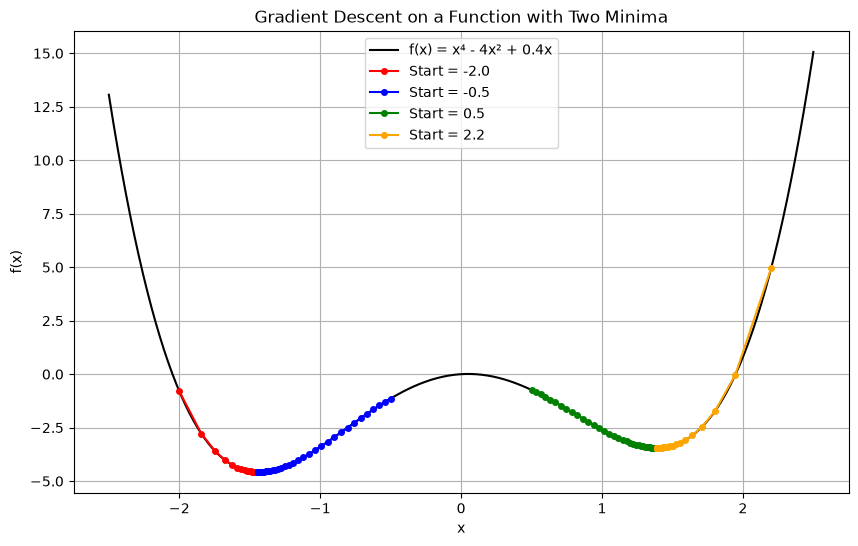

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# Gradient Descent Function
def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history


# Function with two minima
def f(x):
    return x**4 - 4*x**2 + 0.4*x

# Gradient
def grad(x):
    return 4*x**3 - 8*x + 0.4


# Plot the function
x = np.linspace(-2.5, 2.5, 500)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), color="black", label="f(x) = x⁴ - 4x² + 0.4x")

# Different starting points
starts = [-2.0, -0.5, 0.5, 2.2]
colors = ["red", "blue", "green", "orange"]

print("Gradient Descent Results")


for start, color in zip(starts, colors):
    path = gradient_descent(grad, start, 0.01, 200)

    print(f"Start {start:>4} -> End {path[-1]:.3f}")

    plt.plot(
        path,
        [f(i) for i in path],
        "o-",
        color=color,
        markersize=4,
        label=f"Start = {start}"
    )

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on a Function with Two Minima")
plt.grid(True)
plt.legend()
plt.show()

Now contrast with a convex function like (x-2)²: run descent from several starts and confirm they all reach the
same minimum.

Gradient Descent Results
Start -2.0 -> End 1.930
Start -0.5 -> End 1.956
Start  0.5 -> End 1.974
Start  2.2 -> End 2.004


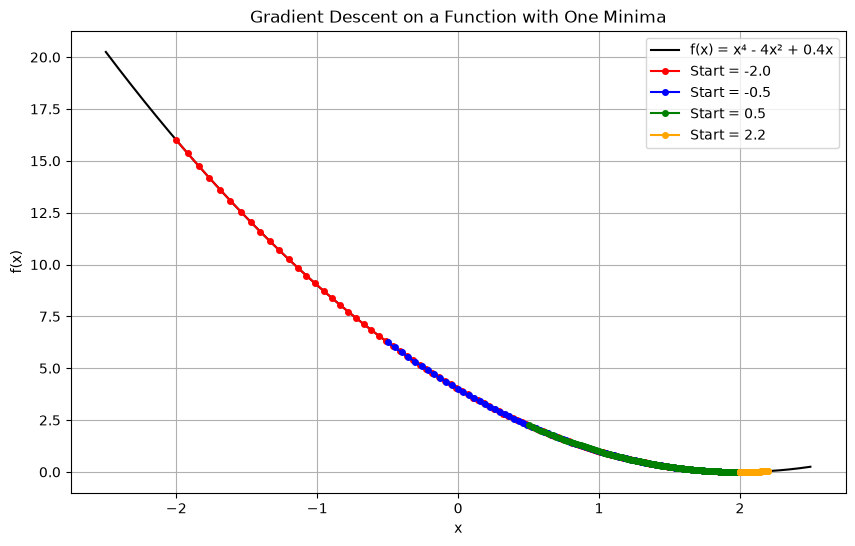

In [13]:
def f(x):
    return (x-2)**2

def grad(x):
    return 2*(x-2)

x = np.linspace(-2.5, 2.5, 500)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), color="black", label="f(x) = x⁴ - 4x² + 0.4x")

# Different starting points
starts = [-2.0, -0.5, 0.5, 2.2]
colors = ["red", "blue", "green", "orange"]

print("Gradient Descent Results")


for start, color in zip(starts, colors):
    path = gradient_descent(grad, start, 0.01, 200)

    print(f"Start {start:>4} -> End {path[-1]:.3f}")

    plt.plot(
        path,
        [f(i) for i in path],
        "o-",
        color=color,
        markersize=4,
        label=f"Start = {start}"
    )


plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on a Function with One Minima")
plt.grid(True)
plt.legend()
plt.show()

• Write two sentences: why does the starting point matter for the bumpy function but not the convex one?

In [ ]:
#   The starting point matters for the bumpy function because it has multiple valleys, but it does not matter for the convex function because it has only one valley.

TASK 05
Gradient descent in 2D on a contour plot

• Take f(x,y) = x² + 3y², whose gradient is (2x, 6y).

• Write a 2D version of gradient descent that steps a point [x, y] against the gradient vector.

• Run it from [4, 4] and confirm it reaches [0, 0].

• Draw the function as a contour plot and overlay the descent path as a connected line of points.

• Notice the path curves rather than heading straight for the minimum. Explain why, using the fact that the bowl is
steeper in y than in x.

• Try a starting point of your own and a different learning rate; observe the path change.

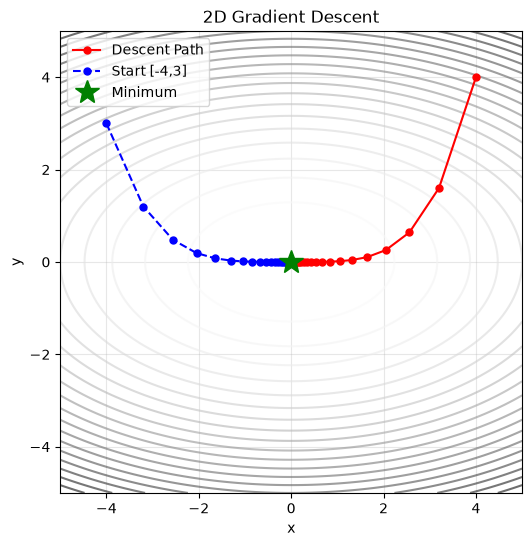

Start [4, 4] -> End [0.0005 0.    ] (True Minimum [0, 0])
Start [-4, 3] -> End [-0.0591  0.    ] (True Minimum [0, 0])


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# f(x,y) = x^2 + 3y^2
def f(x, y):
    return x**2 + 3*y**2

# Gradient = (2x, 6y)
def grad(p):
    return np.array([2*p[0], 6*p[1]])

# 2D Gradient Descent
def gradient_descent_2d(start, lr, steps):
    p = np.array(start, dtype=float)
    path = [p.copy()]

    for _ in range(steps):
        p = p - lr * grad(p)
        path.append(p.copy())

    return np.array(path)


# Run from [4,4]
path = gradient_descent_2d([4.0, 4.0], lr=0.1, steps=40)
path2 = gradient_descent_2d([-4.0, 3.0], lr=0.1, steps=40)

# Contour Plot
xs = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(xs, xs)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(7, 6))

ax.contour(X, Y, Z, levels=20, cmap="Greys", alpha=0.6)

ax.plot(
    path[:, 0],
    path[:, 1],
    "o-",
    color="red",
    markersize=5,
    label="Descent Path"
)
ax.plot(
    path2[:, 0],
    path2[:, 1],
    "o--",
    color="blue",
    markersize=5,
    label="Start [-4,3]"
)

ax.legend()

ax.plot(
    0,
    0,
    "*",
    color="green",
    markersize=18,
    label="Minimum"
)

ax.set_title("2D Gradient Descent")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

print(f"Start [4, 4] -> End {np.round(path[-1], 4)} (True Minimum [0, 0])")


# Try another starting point and learning rate
path2 = gradient_descent_2d([-4.0, 3.0], lr=0.05, steps=40)

print(f"Start [-4, 3] -> End {np.round(path2[-1], 4)} (True Minimum [0, 0])")

TASK 06
Momentum: escape a shallow minimum

• Reuse the two-minima function from Task 04.

• Implement momentum: keep a velocity v, update it as v = beta*v - lr*grad(x), then step x = x + v.
Use beta=0.9.

• Find a starting point on the shallow side (try around x=2.2) where plain gradient descent gets stuck in the
shallow minimum.

• From that same start, run momentum and show it rolls through the hill into the deep global minimum.

• Plot both paths side by side — plain trapped, momentum escaping — marking start and end on each.

• Write two sentences: in physical terms, why does momentum escape the trap when plain descent cannot?

Plain GD End      : 1.388517461192906
Momentum GD End   : -1.4385403897621576


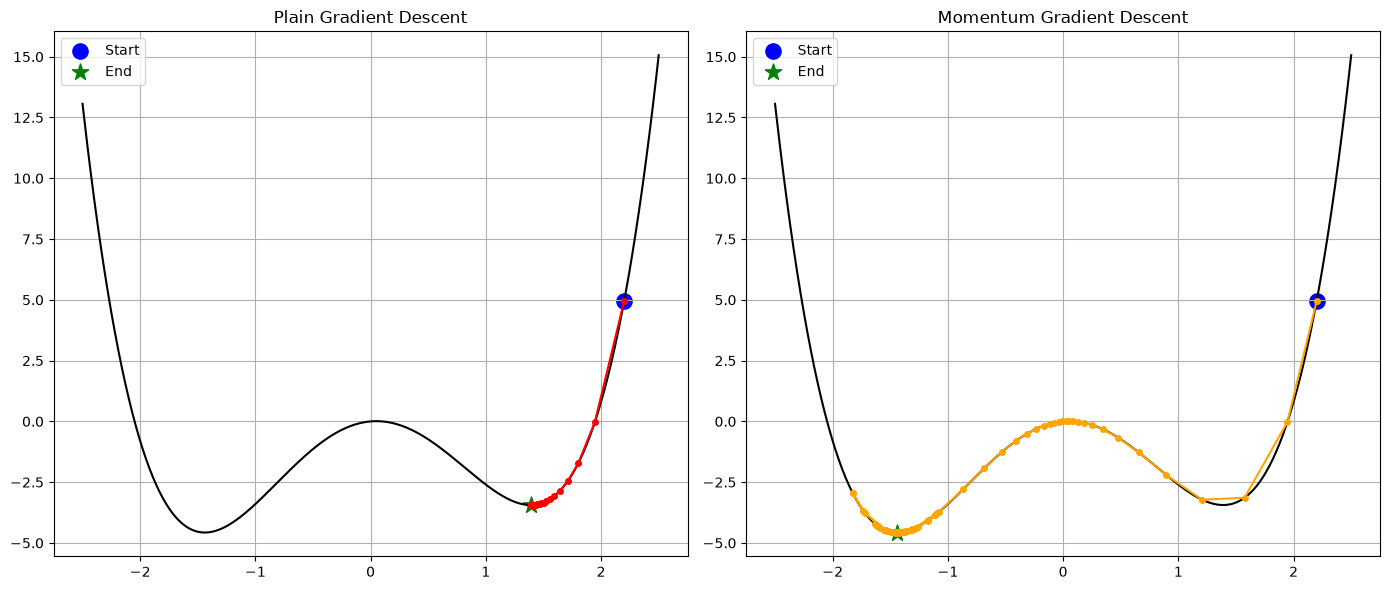

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



def f(x):
    return x**4 - 4*x**2 + 0.4*x

def grad(x):
    return 4*x**3 - 8*x + 0.4


def gradient_descent(start, lr=0.01, steps=200):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad(x)
        history.append(x)

    return history


def momentum_gd(start, lr=0.01, beta=0.9, steps=200):
    x = start
    v = 0.0
    history = [x]

    for _ in range(steps):
        v = beta * v - lr * grad(x)
        x = x + v
        history.append(x)

    return history


# Run both methods

start = 2.2

plain_path = gradient_descent(start)
momentum_path = momentum_gd(start)


print("Plain GD End      :", plain_path[-1])
print("Momentum GD End   :", momentum_path[-1])


x = np.linspace(-2.5, 2.5, 500)
y = f(x)

fig, ax = plt.subplots(1, 2, figsize=(14,6))


ax[0].plot(x, y, color="black")

ax[0].plot(
    plain_path,
    [f(i) for i in plain_path],
    "o-",
    color="red",
    markersize=4
)

ax[0].scatter(
    plain_path[0],
    f(plain_path[0]),
    color="blue",
    s=120,
    marker="o",
    label="Start"
)

ax[0].scatter(
    plain_path[-1],
    f(plain_path[-1]),
    color="green",
    s=150,
    marker="*",
    label="End"
)

ax[0].set_title("Plain Gradient Descent")
ax[0].grid(True)
ax[0].legend()


ax[1].plot(x, y, color="black")

ax[1].plot(
    momentum_path,
    [f(i) for i in momentum_path],
    "o-",
    color="orange",
    markersize=4
)

ax[1].scatter(
    momentum_path[0],
    f(momentum_path[0]),
    color="blue",
    s=120,
    marker="o",
    label="Start"
)

ax[1].scatter(
    momentum_path[-1],
    f(momentum_path[-1]),
    color="green",
    s=150,
    marker="*",
    label="End"
)

ax[1].set_title("Momentum Gradient Descent")
ax[1].grid(True)
ax[1].legend()


plt.tight_layout()
plt.show()